In [18]:
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import torch
import time
import sys
import pandas as pd
import sklearn.gaussian_process as gp
import os
from IPython.display import display, Math

sys.path.append('../nn_model')
sys.path.append('..')
sys.path.append('../data')

sys.path.append('../GP_regr')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
import SR_lib

import nn_model_lib as _lib

from nn_model_lib import *


def import_reload():
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)


import_reload()

## Initial Setup

Specify the RUN_ID, whether you want to save the models after running the optimization. The reference values are specified in `ref_values.csv` file for each run_id. The ref values are updated after data for $s$ has been imported. 

The ref values ensure a reasonable range for the SR. The inputs $(i,d,SOC,s)$ are scaled to be between 0,1. 

In [19]:
RUN_ID = 'test2'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1.5e1)

REF_VALUES = SR_lib.get_ref_values()

UNITS, UNIT_CONV = SR_lib.get_units_dict()

LATEX_DICT = SR_lib.get_latex_dict()

VARIABLES = ['R0','R1', 'C1', 'k', 'sdot', 'Ue']
# Optimization settings for PySR
SELECTION = "best"

if os.path.exists(f'saved_sr_models/{RUN_ID}'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')


## Load the NN model and extract samples

The sample points are obtained by running the `lhs_SR.py` file and saving the values to a .csv file. 

The samples are plotted here to verify the sampling. 

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using Q0_ckpt = 17921.57581, I_ref = 24.89107751102174 and u_ref = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


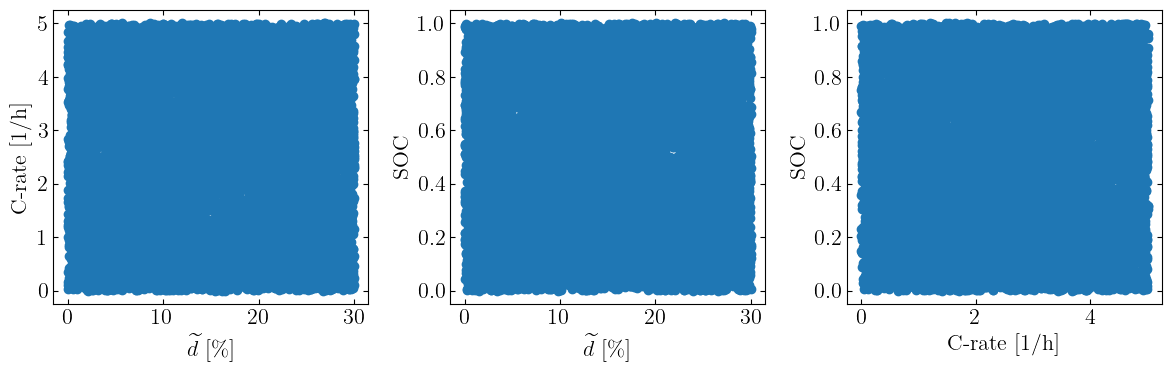

In [20]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('SR_samples.csv', usecols=['u_par', 'C_rate', 'SOC'])

s_data = pd.read_csv('../data/polished_combo/combo_half.txt', delimiter=';')

f, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[0].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[0].set_ylabel('C-rate [1/h]')
ax[1].set_xlabel('C-rate [1/h]')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[1].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[1].set_ylabel('SOC ')
ax[2].plot(df['C_rate'],df['SOC'], 'o')
ax[2].set_xlabel('C-rate [1/h]')
ax[2].set_ylabel('SOC ')
plt.tight_layout()

## Loading data for $s$



In [21]:
s_data_P = s_data[s_data['pulse'] == 1]

trajs = prepare_pulse_data(s_data_P)
s_df_p = data_param(BAT_MODEL, trajs, pulse = True)

s_data_CC = s_data[s_data['pulse'] == 0]
trajs = prepare_data(s_data_CC)
s_df_cc = data_param(BAT_MODEL, trajs, pulse = False)
s_df_tot = pd.concat([s_df_p, s_df_cc], ignore_index=True)

s_data = s_df_tot[['I', 'u_per', 'soc', 's', 'sdot']].copy()
REF_VALUES['s'] = s_data['s'].max()

s_data['C'] = s_data['I'] * 3600 / Q0


s_data['s'] = s_data['s'] / REF_VALUES['s']

s_data['C'] = s_data['C'] / REF_VALUES['C']

s_data['u_per'] = s_data['u_per'] / REF_VALUES['d']

s_data['sdot'] = s_data['sdot'] / REF_VALUES['sdot']
s_data.describe()



,I,u_per,soc,s,sdot,C
count,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000
mean,6.959620,0.429038,0.544854,0.294561,0.869936,0.279603
std,6.807070,0.309418,0.257924,0.240674,1.009850,0.273474
min,0.000000,0.000000,0.024633,0.000000,0.003351,0.000000
25%,0.000000,0.176667,0.329973,0.093446,0.087223,0.000000
50%,4.480394,0.406667,0.548750,0.227796,0.599727,0.180000
75%,10.952074,0.686667,0.762836,0.459088,1.125820,0.440000
max,24.891078,0.990000,1.000000,1.000000,5.313158,1.000000


### Save the reference value for $s$

In [22]:
# Save reference values for simulating the observed outputs. 

save_refvalues = True
if save_refvalues:
    df_ref = pd.DataFrame(REF_VALUES, index=[0])
    df_existing = pd.read_csv("saved_sr_models/ref_values.csv")
    if RUN_ID in df_existing['run_id'].values:
        print(f'Run ID {RUN_ID} already exists in ref_values.csv. Did not save new reference values.')
    else:
        df_ref.to_csv(f'saved_sr_models/ref_values_{RUN_ID}.csv', index=False)
        df_ref['run_id'] = RUN_ID
        df_new = pd.DataFrame(df_ref, columns=df_existing.columns.values)
        df_combined = pd.concat([df_existing,df_new], ignore_index=True)
        df_combined.to_csv("saved_sr_models/ref_values.csv", index=False)

        #df_combined.to_excel("exp_log/Euler_exps.xlsx", index=False)

Run ID test2 already exists in ref_values.csv. Did not save new reference values.


## Defining functions for computing the elements

In [23]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def sample_element(c_rate, u_per, soc):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    return R0.item(), R1.item(), C1.item(), k.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),4+3))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        r0, r1,c1,k = sample_element(c_rate, u_per, soc)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], c_rate, u_per, soc]
    return samples


### Generating samples and displaying the df for $R_0$, $R_1$, $C_1$ and $k$

In [24]:
samples = generate_data(df.values)
VARIABLES = ['R0','R1', 'C1', 'k']
N_VAR = len(VARIABLES)
cols = VARIABLES + ['C', 'u_per', 'soc']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples
data['u_per'] =  data['u_per'] / REF_VALUES['d']
data['C'] =  data['C'] / REF_VALUES['C']
data.describe() 

100%|██████████| 10000/10000 [00:08<00:00, 1150.19it/s]


,R0,R1,C1,k,C,u_per,soc
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.823645,5.678430,9.447663,2.887359,0.499987,0.499977,0.499957
std,0.149276,10.257809,3.838857,0.377416,0.288700,0.288720,0.288703
min,0.400871,0.188216,0.123883,2.239312,0.000000,0.000000,0.000000
25%,0.744825,0.592013,10.566363,2.558353,0.249950,0.250008,0.250000
50%,0.809587,0.721194,11.240972,2.840583,0.500000,0.500017,0.500000
75%,0.877739,1.949865,11.378365,3.192075,0.750000,0.749958,0.750000
max,1.482466,28.958312,13.489980,3.777907,1.000000,0.999900,1.000000


### Visual overview of the scaled values

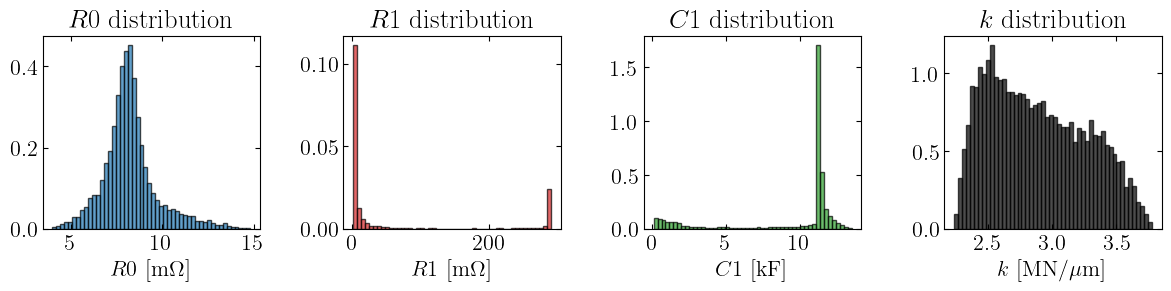

In [25]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var]*UNIT_CONV[var]*REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [26]:
def get_XY(d_frame, s_frame = None):
    '''Get input and output arrays for symbolic regression. If s_frame is provided, also return sdot values and corresponding inputs.'''

    if s_frame is not None:
        for i in range(1,10):
            inds = np.arange(0,len(s_frame)) % i == 0
            if inds.sum() < 1e4:
                break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values 
    Y_R1 = d_frame['R1'].values 
    Y_C1 = d_frame['C1'].values 
    Y_k  = d_frame['k'].values  
    if s_frame is not None:
        Y_s = s_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = s_frame[['C', 'u_per', 'soc', 's']].values
        Y_s = Y_s[inds]
        X_s = X_s[inds]
    else: 
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)
    
    return X,Y_R0, Y_R1 ,Y_C1, Y_k, Y_s, X_s

### Get training and test data 

In this case, the test data is not used. So the split is neglected. 

In [27]:
split_train = int(len(data) * 0.8)
s_split_train = int(len(s_data) * 0.8)

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = SR_lib.prepare_data(data_train)
    trajs_test  = SR_lib.prepare_data(data_test)
else:
    data_train  = data#[:split_train]
    data_test   = data#[split_train:]
    s_data_train = s_data#[:s_split_train]
    s_data_test = s_data#[s_split_train:]


X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train, s_frame = s_data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test, s_frame = s_data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    'sdot':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    'sdot':  Ys_test
}



# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.022280997
Equation: 0.8237903

Model 1: Complexity=3, Loss=0.021061784
Equation: sqrt(sqrt(soc))

Model 2: Complexity=4, Loss=0.018072037
Equation: sqrt(soc + 0.2418471)

Model 3: Complexity=5, Loss=0.00911741
Equation: sqrt(cube(soc) - -0.46144637)

Model 4: Complexity=6, Loss=0.0073219896
Equation: cube(soc - 0.2605543) + 0.7291209

Model 5: Complexity=8, Loss=0.006512917
Equation: sqrt(exp((cube(soc) * soc) + -0.6024581))

Model 6: Complexity=10, Loss=0.004236591
Equation: (C * -0.17692165) + sqrt(exp(cube(soc) + -0.45982084))

Model 7: Complexity=12, Loss=0.004011569
Equation: ((C + 0.7785376) * -0.21420431) + sqrt(exp(cube(soc + -0.08332959)))

Model 8: Complexity=13, Loss=0.0039119055
Equation: cube(exp((cube(sqrt(soc) + -0.4848109) + -0.09235624) * (C + d)))

Model 9: Complexity=14, Loss=0.0036629944
Equation: cube(exp((C + sqrt(d)) * (cube(sqrt(soc) + -0.4848109) + -0.09235624)))

Model 10: Complexity=15, Loss=0.0025081558
Equation: square(exp(((C 

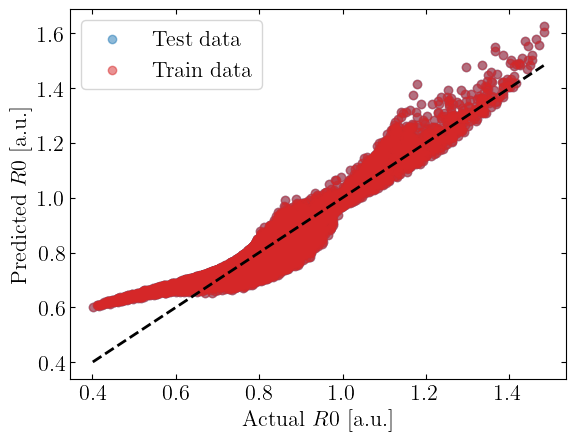

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp(-0.2152439*C - 0.2152439*sqrt(d) + 2*(sqrt(soc**3) - 0.3491735)**3)
Loss: 0.0025081558
Best model complexity: 15


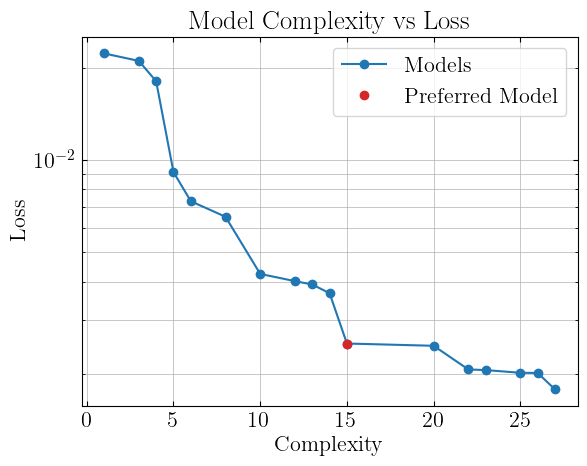

In [28]:
import_reload()
model_R0 = SR_lib.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
SR_lib.print_models(df_model_R0)
import_reload() 
SR_lib.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
SR_lib.print_best_model(model_R0)
SR_lib.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Variable names for element R1: ['C', 'd', 'soc']
Running symbolic regression for element R1 with run_id R1_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=105.212135
Equation: 5.681959

Model 1: Complexity=3, Loss=97.50866
Equation: C * 10.925901

Model 2: Complexity=4, Loss=72.25265
Equation: cube(2.3092113 - soc)

Model 3: Complexity=5, Loss=38.791874
Equation: cube(cube(1.4880499 - soc))

Model 4: Complexity=6, Loss=38.786808
Equation: cube((0.7136887 - soc) * 4.2537484)

Model 5: Complexity=7, Loss=22.607014
Equation: cube(cube(1.3932688 - soc) + C)

Model 6: Complexity=9, Loss=22.342518
Equation: cube(cube(1.3988225 - soc) + C) - 0.8087292

Model 7: Complexity=10, Loss=21.997375
Equation: cube(C + cube((1.3916515 - soc) - cube(soc)))

Model 8: Complexity=14, Loss=21.768463
Equation: cube(C + cube((1.3217665 - soc) + (0.06988505 - cube(soc)))) + C

Model 9: Complexity=18, Loss=21.386677
Equation: (((C + C) + 0.5577219) * sqrt(square((cube(soc - 0.7984721) * -38.15156) + C))) + -1.1809521

Model 10: Complexity=20, Loss=21.326622
Equation: -1.1809521 + (((C + C) + 0.5577219) * (sqrt(square((2.0116825 / -0.05

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (C + (1.3932688 - soc)**3)**3
Loss: 22.607014
Best model complexity: 7


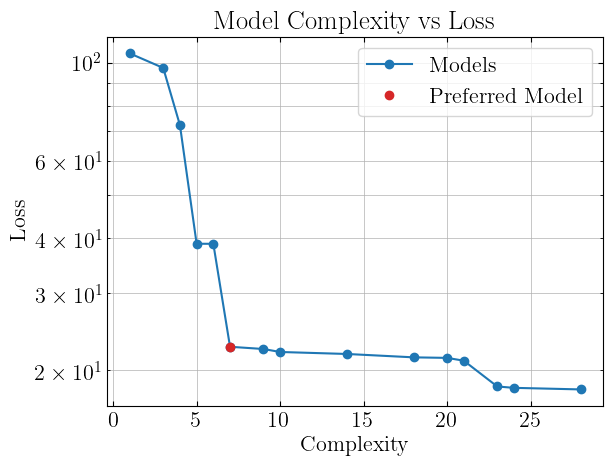

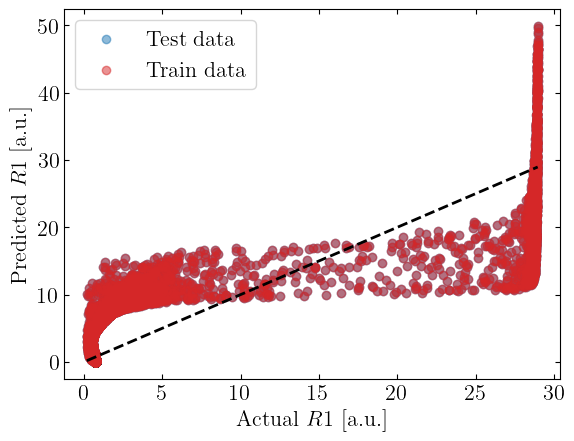

In [29]:
import_reload()
model_R1 = SR_lib.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
SR_lib.print_models(df_model_R1)
SR_lib.print_best_model(model_R1)
SR_lib.pareto_plot(model_R1)
SR_lib.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Variable names for element C1: ['C', 'd', 'soc']
Running symbolic regression for element C1 with run_id C1_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=14.735353
Equation: 9.448641

Model 1: Complexity=3, Loss=13.298125
Equation: soc + 8.957834

Model 2: Complexity=4, Loss=6.1473923
Equation: sqrt(soc) * 13.078532

Model 3: Complexity=6, Loss=5.6126122
Equation: (sqrt(soc) * 12.933558) + 0.8198811

Model 4: Complexity=7, Loss=4.632789
Equation: (-0.86072797 / (soc - -0.042098023)) + 12.404326

Model 5: Complexity=9, Loss=3.6538305
Equation: exp(2.441655 - exp(soc * (soc * -18.120916)))

Model 6: Complexity=11, Loss=2.4941335
Equation: exp(2.441655 - exp((soc * (soc * -18.120916)) + C))

Model 7: Complexity=12, Loss=0.5050129
Equation: exp(2.441655 - cube(exp(((soc * soc) * -18.120916) + C)))

Model 8: Complexity=14, Loss=0.4959896
Equation: exp(2.441655 - cube(exp(((soc * soc) * -18.120916) + (C / 0.90690565))))

Model 9: Complexity=16, Loss=0.33621532
Equation: sqrt(C) + exp(2.3854227 - square(cube(exp(C + ((soc * -14.840327) * soc)))))

Model 10: Complexity=19, Loss=0.25309026
Equation: C + exp(2.3885028 

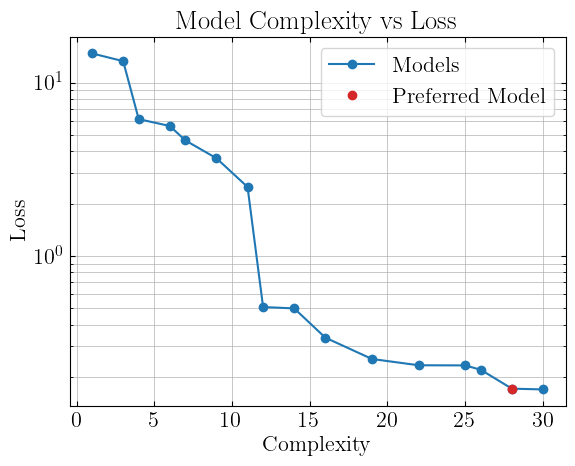

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: C - soc*soc + soc + exp(2.3811765 - exp(3*1.3059114**C + 3*soc**C*(-13.61692)*soc - 3*soc))
Loss: 0.17052159
Best model complexity: 28


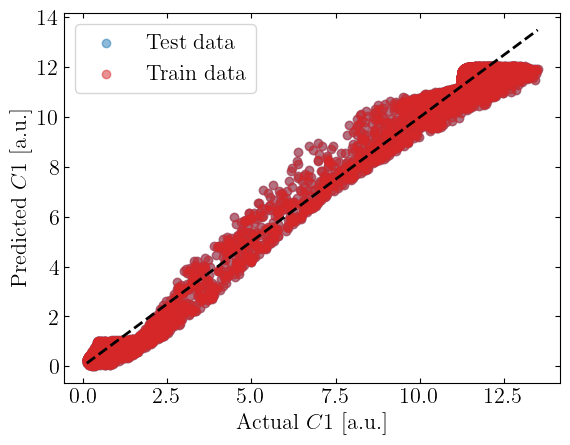

In [30]:
import_reload()
model_C1 = SR_lib.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
SR_lib.print_models(df_model_C1)
SR_lib.pareto_plot(model_C1)
SR_lib.print_best_model(model_C1)
SR_lib.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Variable names for element k: ['C', 'd', 'soc']
Running symbolic regression for element k with run_id k_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.14242908
Equation: 2.8877265

Model 1: Complexity=3, Loss=0.015178812
Equation: d + 2.3873506

Model 2: Complexity=4, Loss=0.01499402
Equation: square(d) + 2.5570874

Model 3: Complexity=5, Loss=0.009408671
Equation: (d + 1.782553) * 1.2663151

Model 4: Complexity=6, Loss=0.007993103
Equation: exp(d + -0.28803387) - -1.5969608

Model 5: Complexity=7, Loss=0.007855034
Equation: (soc * -0.3036939) + (d - -2.5338023)

Model 6: Complexity=8, Loss=0.0076707155
Equation: (square(d) + 2.7032275) - (soc * 0.29698625)

Model 7: Complexity=9, Loss=0.0055082077
Equation: (((soc * -0.34097585) + 1.5060129) * d) - -2.2654798

Model 8: Complexity=10, Loss=0.00016470374
Equation: exp((d + -0.17261463) - (soc / 4.3220396)) + 1.5957321

Model 9: Complexity=12, Loss=0.00016159029
Equation: exp((d + -0.18197691) - ((soc + soc) * 0.11381608)) + 1.6063366

Model 10: Complexity=17, Loss=7.30323e-05
Equation: (exp((d + ((-0.82118213 - (soc + -0.09268372)) / 4.5883284)) * 0.65272

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 0.021270733*sqrt(soc) + (0.844209242913715*exp(0.6422337*d - 0.159825342865317*soc) + 1.0647386)**1.3686612
Loss: 4.0503666e-05
Best model complexity: 20


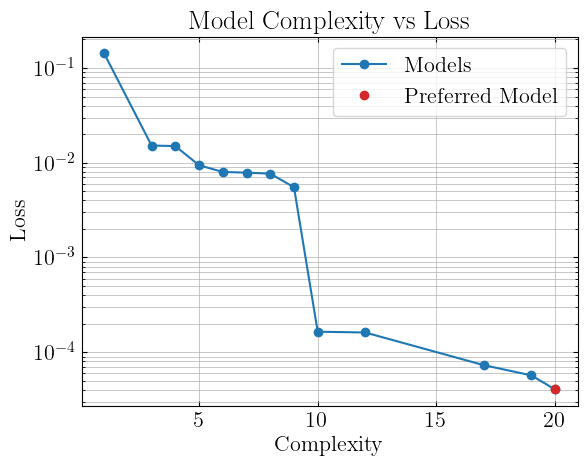

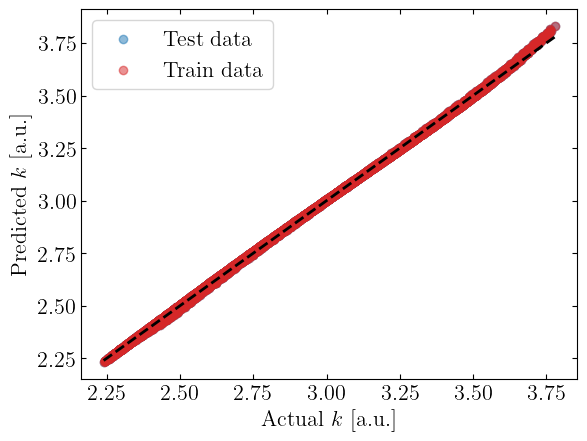

In [31]:
import_reload()
model_k = SR_lib.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
SR_lib.print_models(df_model_k)
SR_lib.print_best_model(model_k)
SR_lib.pareto_plot(model_k)
SR_lib.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(i,d,\mathrm{SOC},s)$

Variable names for element sdot: ['C', 'd', 'soc', 's']
Running symbolic regression for element sdot with run_id sdot_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=1.0207504
Equation: 0.8736119

Model 1: Complexity=2, Loss=0.7823736
Equation: exp(C)

Model 2: Complexity=3, Loss=0.38233283
Equation: C * 3.0107863

Model 3: Complexity=4, Loss=0.36027333
Equation: exp(C) - d

Model 4: Complexity=5, Loss=0.24479139
Equation: C * (3.432771 - d)

Model 5: Complexity=6, Loss=0.045688044
Equation: square(2.2117279 - d) * C

Model 6: Complexity=7, Loss=0.009804656
Equation: cube(1.6859791 - square(d)) * C

Model 7: Complexity=9, Loss=0.009804652
Equation: C * cube((1.8704414 - square(d)) + -0.18446237)

Model 8: Complexity=11, Loss=0.009621891
Equation: (C * cube(-0.18446237 + (1.8704414 - square(d)))) + 0.008575433

Model 9: Complexity=12, Loss=0.0076221507
Equation: square(exp((0.8511725 - d) * exp(d))) * (C / 1.0987815)

Model 10: Complexity=13, Loss=0.0070227627
Equation: ((cube(square(d - 1.0627482) + -1.5249742) - d) + 5.0826907) * C

Model 11: Complexity=16, Loss=0.0069252993
Equation: ((cube(square(d - 1.0627482) + -1.5

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: C*exp(2*(0.8511725 - d)*exp(d))/1.0987815
Loss: 0.0076221507
Best model complexity: 12


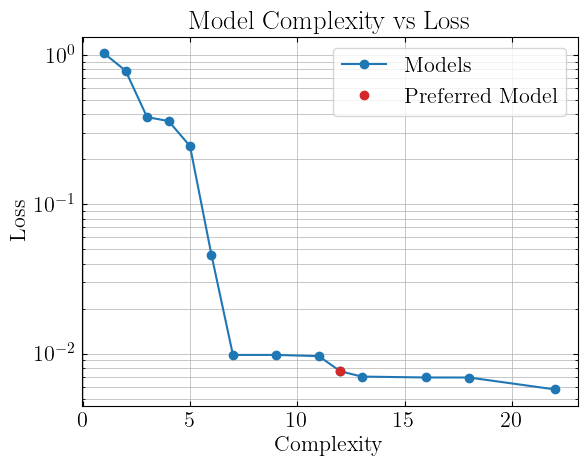

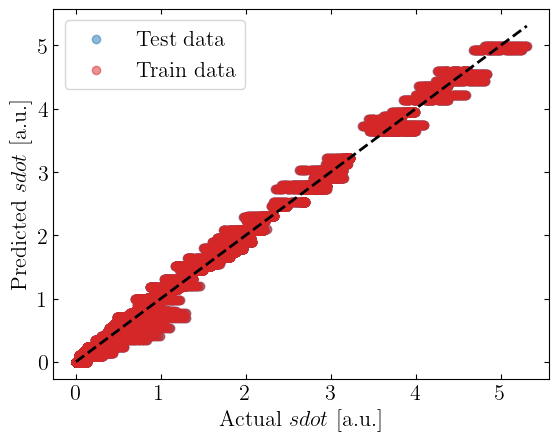

In [32]:
import_reload()
model_s = SR_lib.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f'sdot_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'sdot')
df_model_s = model_s.equations_
SR_lib.print_models(df_model_s)
SR_lib.print_best_model(model_s, s = True)
SR_lib.pareto_plot(model_s)
SR_lib.parity_plot('sdot',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

## Save the models

In [33]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    'sdot':  model_s
}

In [34]:
if SAVE:
    SR_lib.save_expressions(df_model_R0, f'R0_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_s, f'sdot_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_s.get_best(), f'sdot_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_k,  f'k_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_R1, f'R1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_C1, f'C1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}', run_id = RUN_ID)